# Week 06 (Module 17) - BBO capstone driver

Round 6. Three rounds in a row with no new bests (W3=1, W4=0, W5=0) but the surrogate trust scores have improved on four of eight functions. This round is about leveraging that improved trust where it exists and being patient where it's still emerging.

**New tech this round: trend-aware trust gate.** R² history is now reconstructed for W1-W6 and persisted to `data/r2_history.csv`. The strategy gate combines current R² *and* trend (improving / stable / declining) to decide whether to exploit, balance, or stay model-free.

**W6 gate decisions per function:**
- **f1** (R²=-0.25, IMPROVING) → RECOVERING → `space_fill` (trajectory positive but still negative)
- **f2** (R²=+0.58, STABLE) → PARTIAL → AEI conservative
- **f3** (R²=+0.67, STABLE) → PARTIAL → AEI conservative (big W6 jump needs one more confirming round before promoting to EI)
- **f4** (R²=+0.98, STABLE) → RELIABLE → EI exploit
- **f5** → MANUAL OVERRIDE to (0,0,0,0): test the opposite corner for a hidden second peak (peak at (1,1,1,1)=8662 is sharp and confirmed; can always re-submit in final week)
- **f6** (R²=-0.05, STABLE) → BROKEN → `space_fill`
- **f7** (R²=+0.12, STABLE) → technically PARTIAL but stuck for 4 rounds → manual override to `space_fill`
- **f8** (R²=+0.99, STABLE) → RELIABLE → MES (RF-flagged x5 probe pencilled for W7 if MES stays converged)

Five weeks remaining before final submission; this round buys information on the peripheral functions and tests f5's global-vs-local hypothesis.


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

WEEK = 6
KIND = "matern"
SEED = 0

BALANCED = dict(acq="ei",  xi=0.01)
INFO     = dict(acq="mes")
AEI_CONS = dict(acq="aei", xi=0.10)
SPACEFIL = dict(acq="space_fill")

# W6 plan: gated by combined R² + trend.
# f5 is handled manually below (override to (0,0,0,0) for opposite-corner test).
PLAN = {}
PLAN[1] = dict(SPACEFIL)          # RECOVERING
PLAN[2] = dict(AEI_CONS)          # PARTIAL stable
PLAN[3] = dict(AEI_CONS)          # PARTIAL - patient before promotion
PLAN[4] = dict(BALANCED)          # RELIABLE
PLAN[5] = dict(BALANCED)          # placeholder - overridden manually
PLAN[6] = dict(SPACEFIL)          # BROKEN
PLAN[7] = dict(SPACEFIL)          # stuck-near-zero override
PLAN[8] = dict(INFO)              # RELIABLE

OUTDIR = f"outputs/week{WEEK:02d}"
os.makedirs(OUTDIR, exist_ok=True)
pd.DataFrame([dict(func=f"f{fid}", **PLAN[fid]) for fid in bo.FUNC_IDS])


,func,acq,xi
0,f1,space_fill,NaN
1,f2,aei,0.10
2,f3,aei,0.10
3,f4,ei,0.01
4,f5,ei,0.01
5,f6,space_fill,NaN
6,f7,space_fill,NaN
7,f8,mes,NaN


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
results = {fid: bo.run_function(fid, kind=KIND, seed=SEED, **PLAN[fid]) for fid in bo.FUNC_IDS}

summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4),
         pred_std=round(results[fid]["std"], 4),
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary
# Manual override applied at submission time: f5 probes the opposite corner (0,0,0,0)
# to test for a hidden second peak. The (1,1,1,1)=8662 peak is banked for the final week.
f5_x = np.array([0.000000, 0.000000, 0.000000, 0.000000])
m5 = results[5]["model"]
mu5, sd5 = m5.predict(bo.to_unit(f5_x.reshape(1,-1), m5.b))
results[5].update(x=f5_x, u=bo.to_unit(f5_x.reshape(1,-1), m5.b).reshape(-1),
                  submission=bo.format_submission(f5_x), acq="manual_probe",
                  mean=float(mu5[0]), std=float(sd5[0]))
results[5]["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m5, np.atleast_2d(results[5]["u"])).items()}
summary


,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,15,0.0000,-0.0002,0.0009,space_fill,0.001142-0.002684
1,f2,2,15,0.6112,0.3222,0.1197,aei,0.920285-0.040059
2,f3,3,20,-0.0348,-0.0159,0.0412,aei,0.961192-0.999999-0.406087
3,f4,4,35,0.5401,0.9796,0.2225,ei,0.377486-0.408091-0.419897-0.447836
4,f5,4,25,8662.4050,8619.7414,138.6955,ei,0.999999-0.000000-0.000000-0.999999
5,f6,5,25,-0.7048,-1.7255,0.4082,space_fill,0.352338-0.020636-0.915072-0.017724-0.962404
6,f7,6,35,1.6876,0.1086,0.3014,space_fill,0.830424-0.954173-0.844299-0.021565-0.647295-0...
7,f8,8,45,9.9498,9.9497,0.0013,mes,0.121700-0.148903-0.117654-0.213828-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])

,func,ei,ucb,pi,var
0,f1,0.0000,0.0017,0.0000,0.000000e+00
1,f2,0.0000,0.5617,0.0006,1.430000e-02
2,f3,0.0004,0.0665,0.0245,1.700000e-03
3,f4,0.4317,1.4246,0.9732,4.950000e-02
4,f5,0.0000,2948.3890,0.0000,1.780799e+06
5,f6,0.0008,-0.9090,0.0058,1.667000e-01
6,f7,0.0000,0.7114,0.0000,9.080000e-02
7,f8,0.0000,9.9523,0.0000,0.000000e+00


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

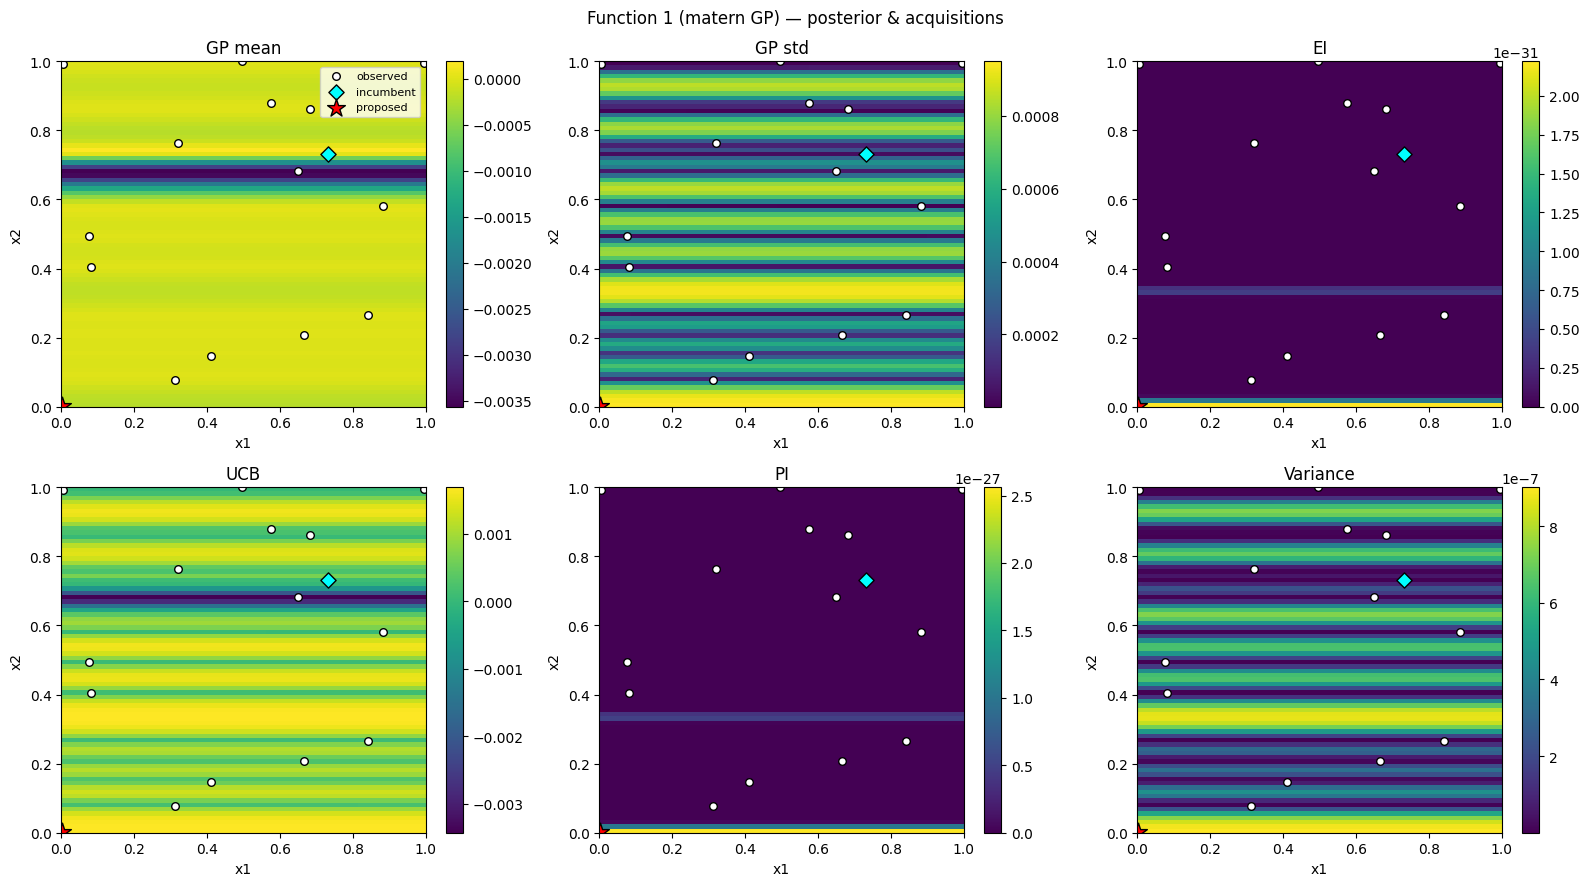

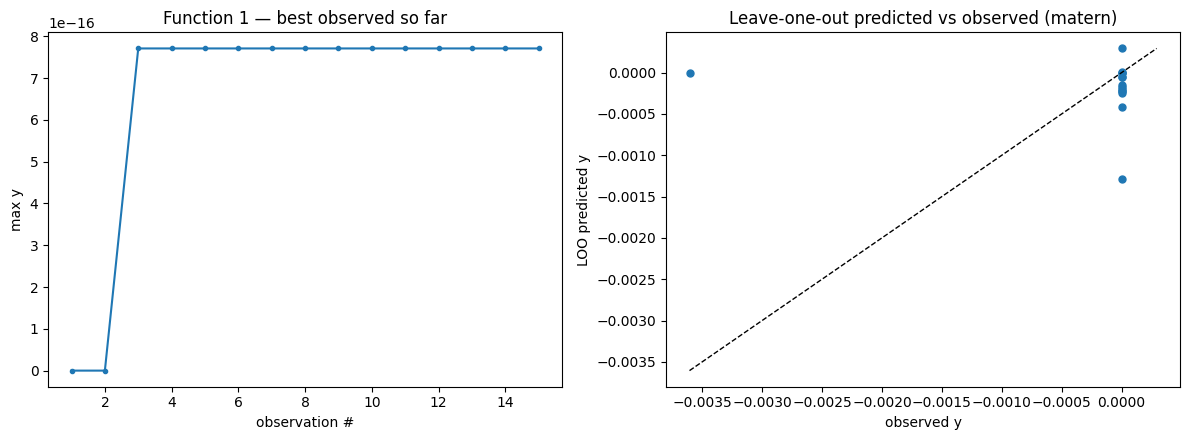

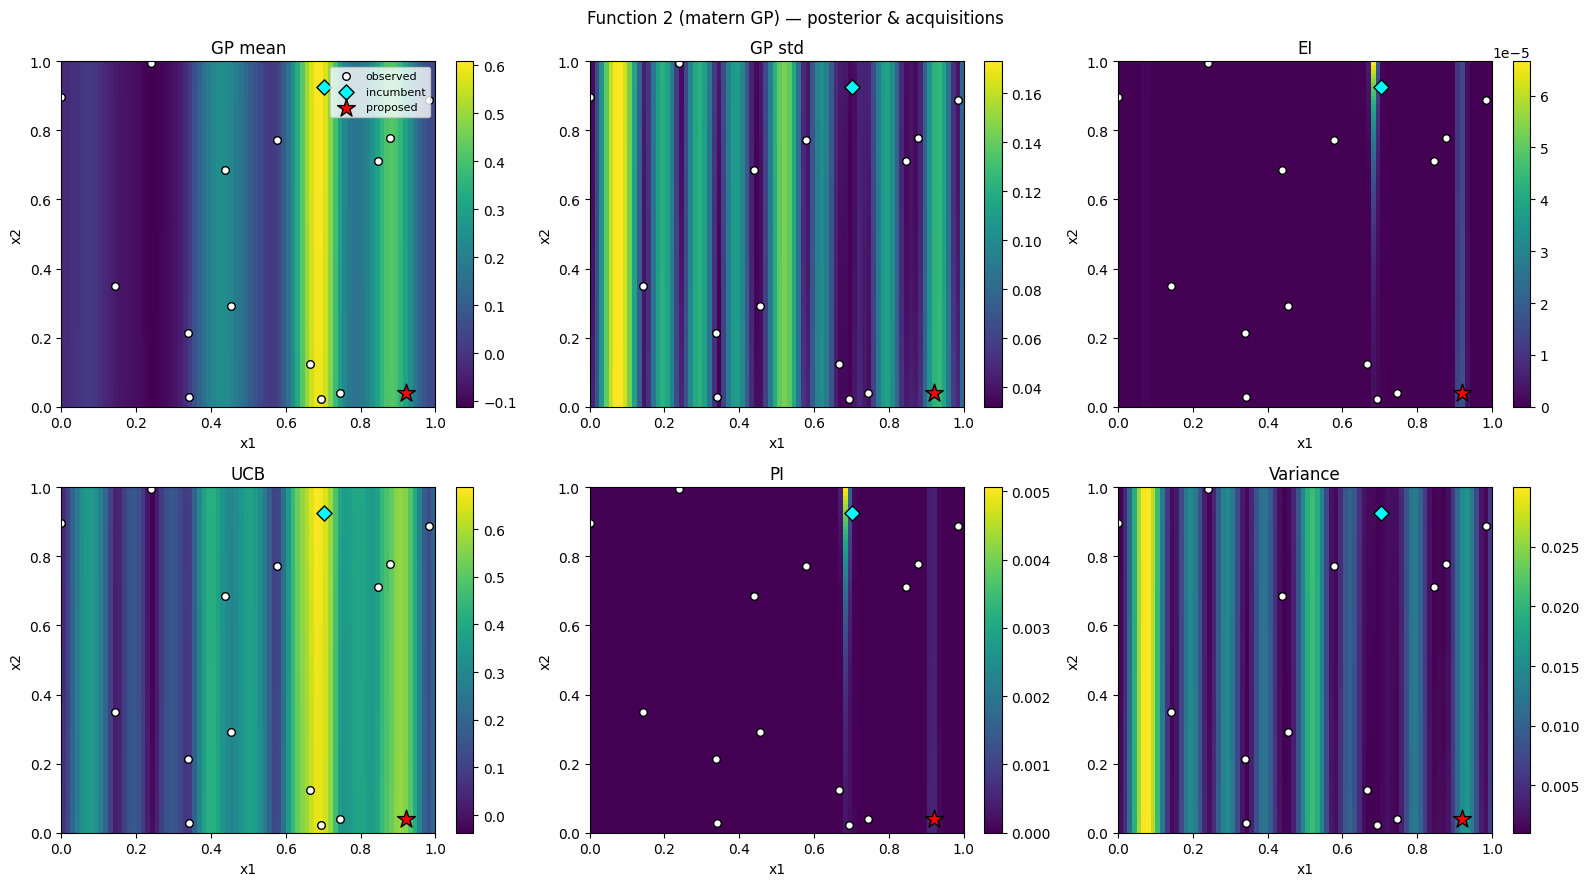

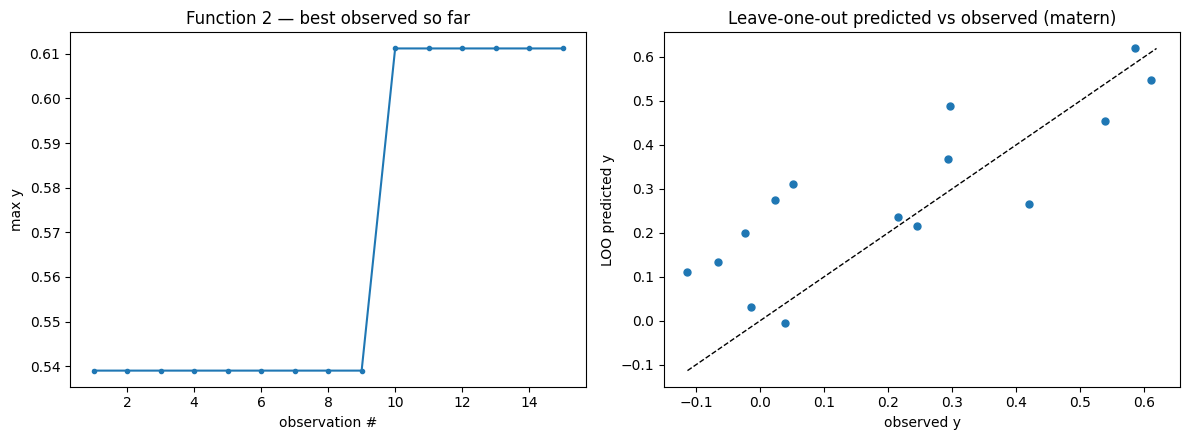

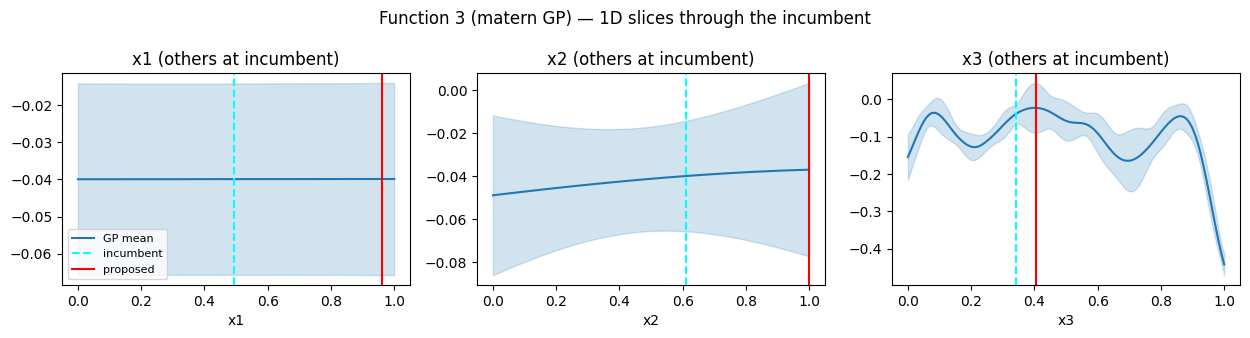

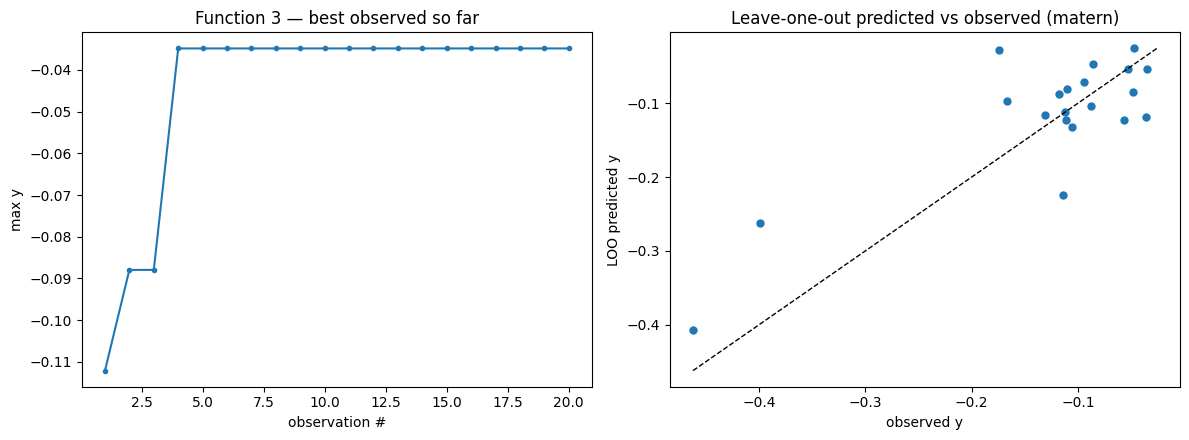

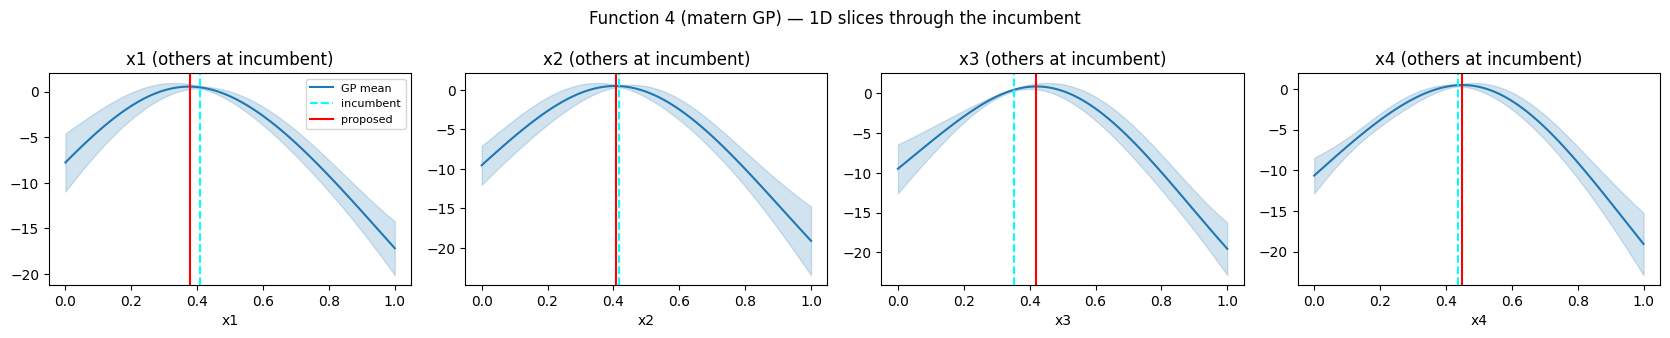

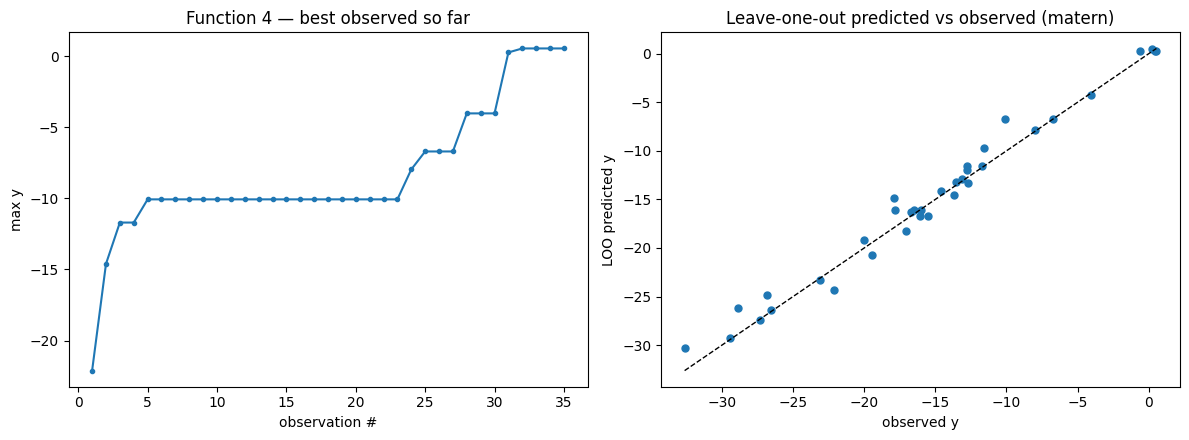

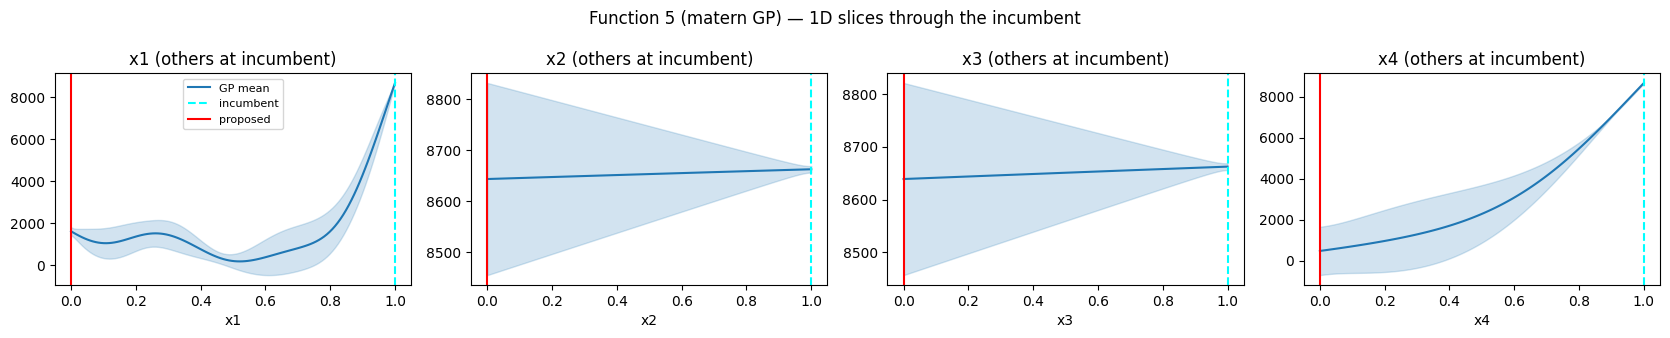

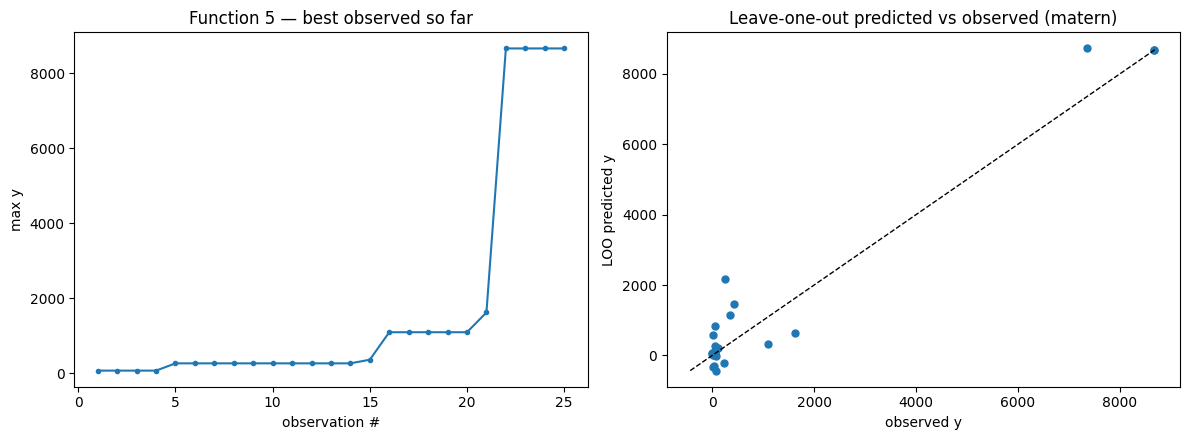

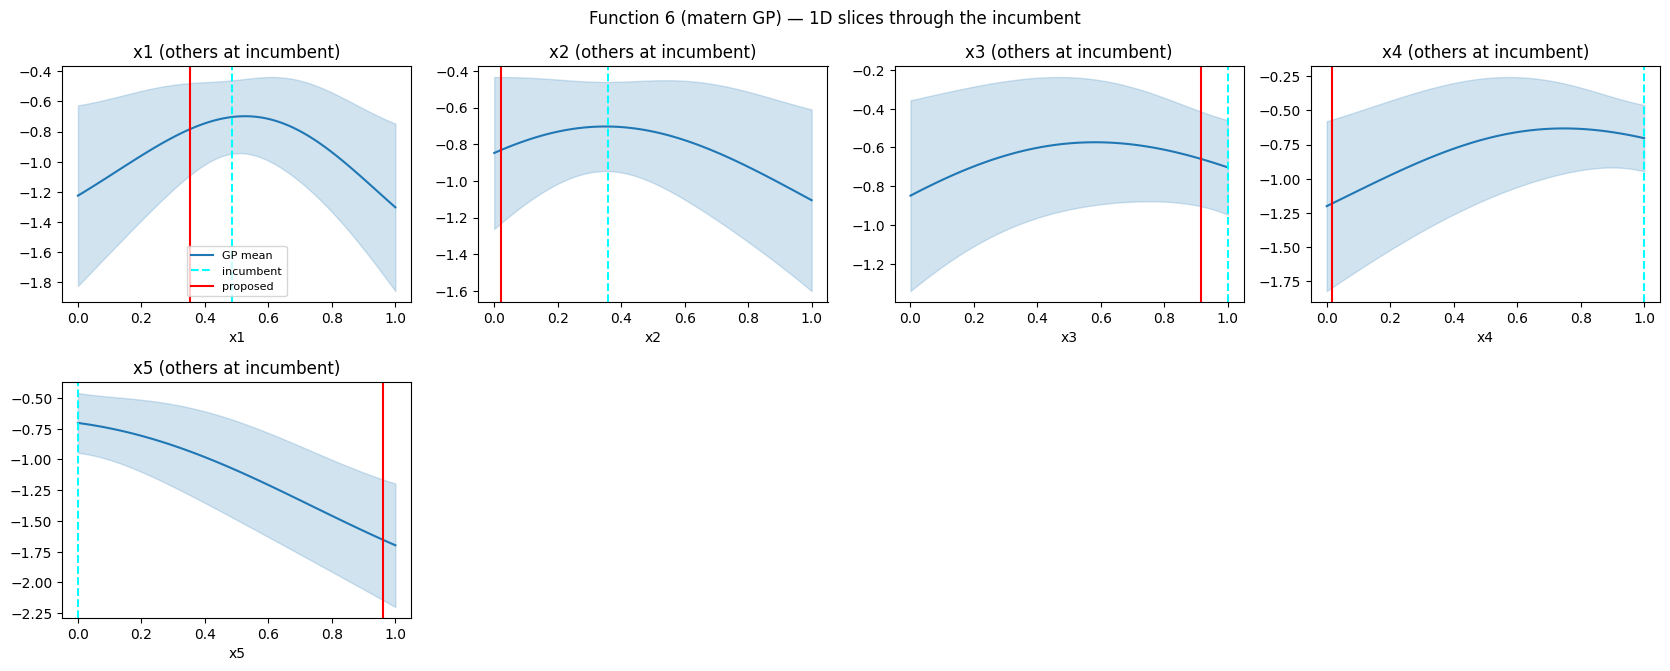

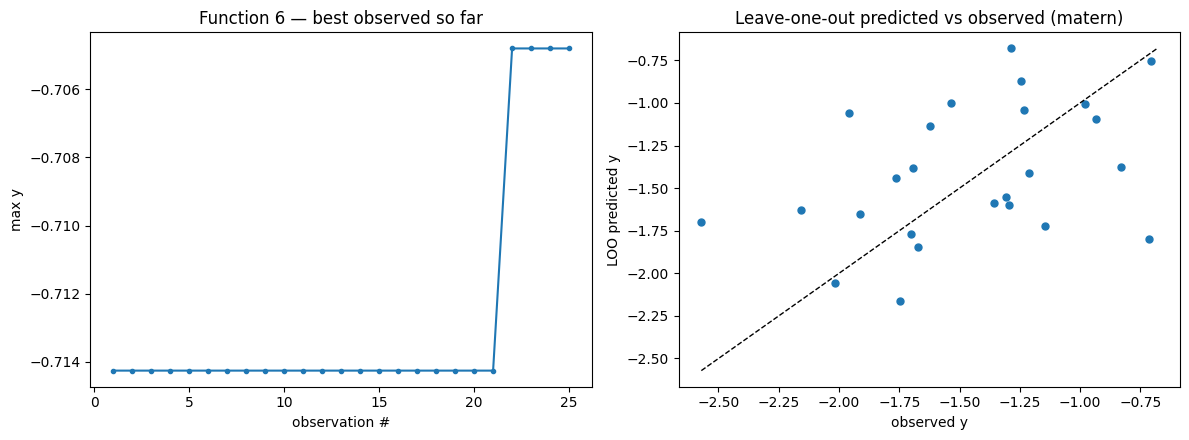

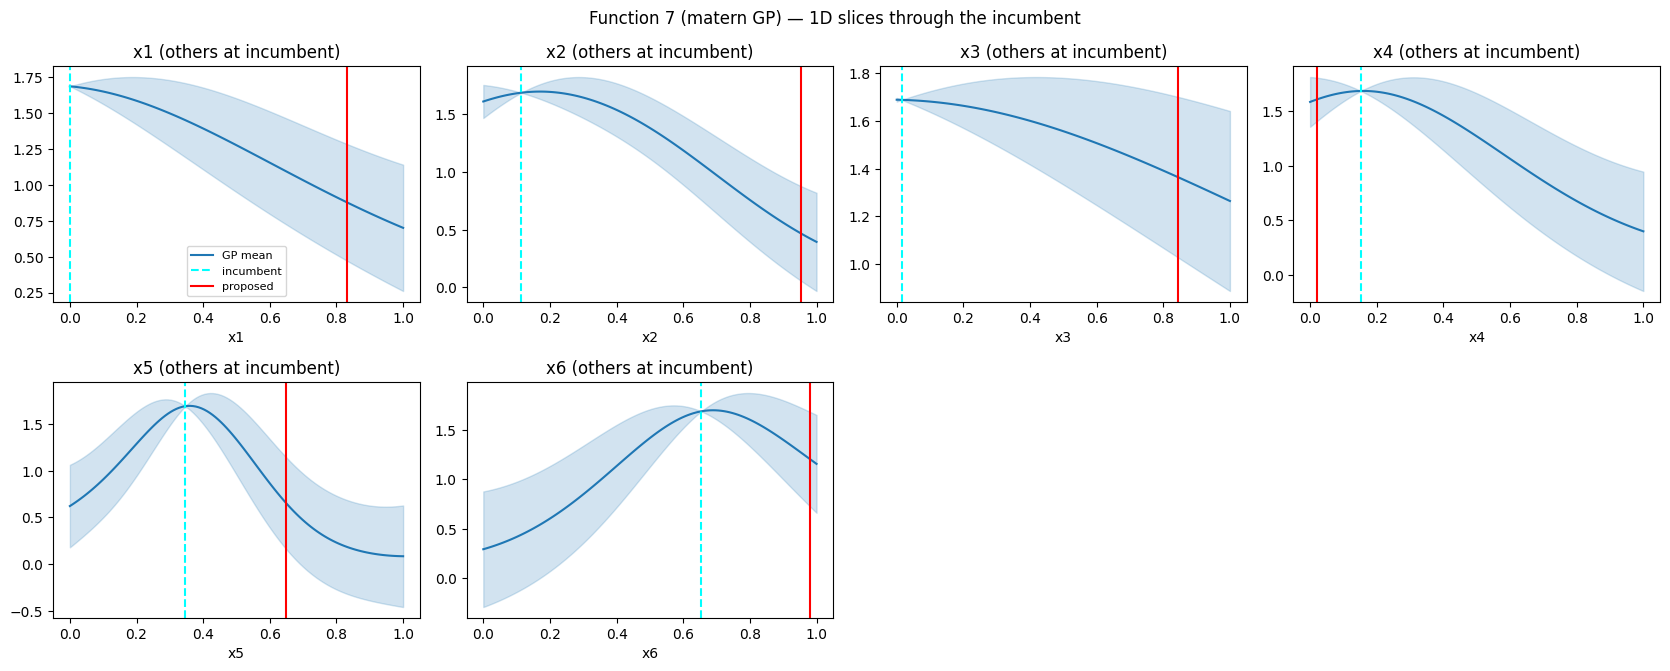

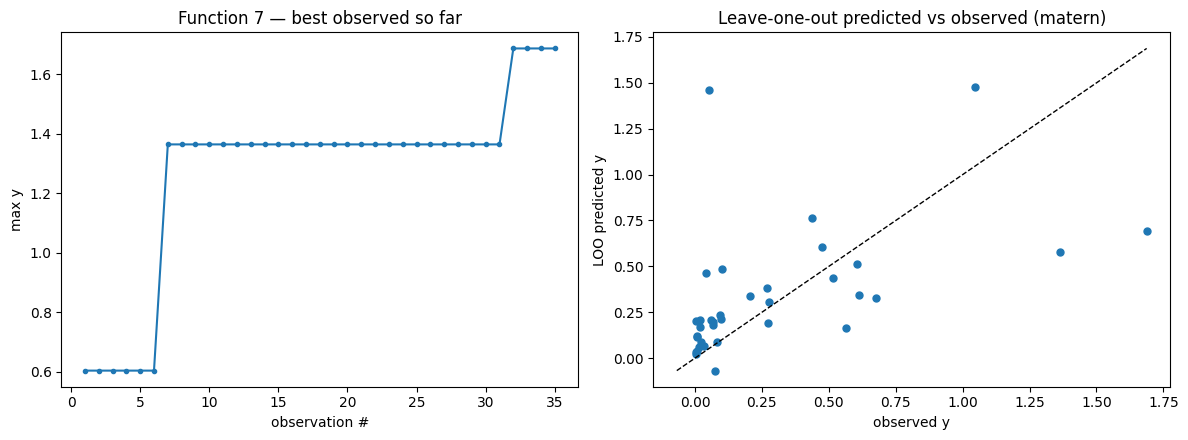

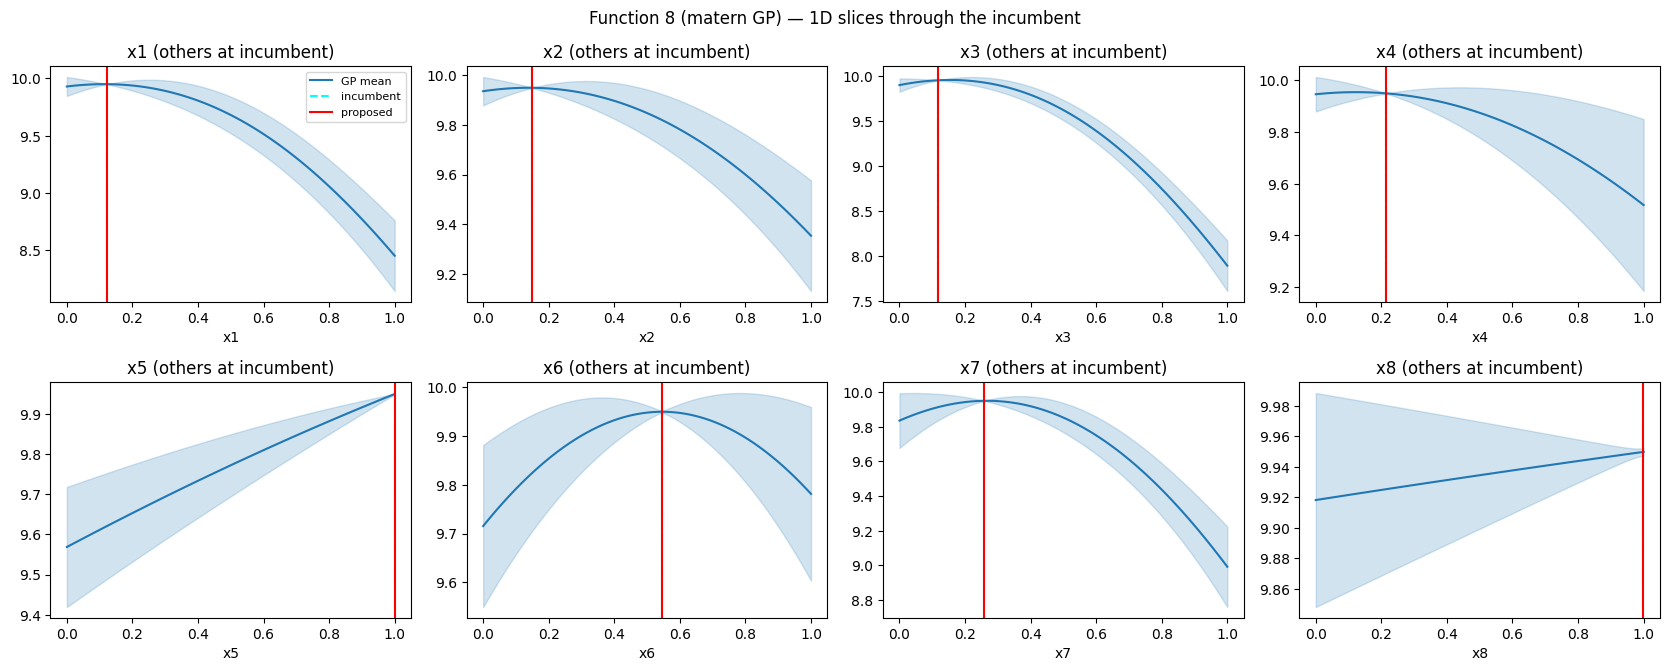

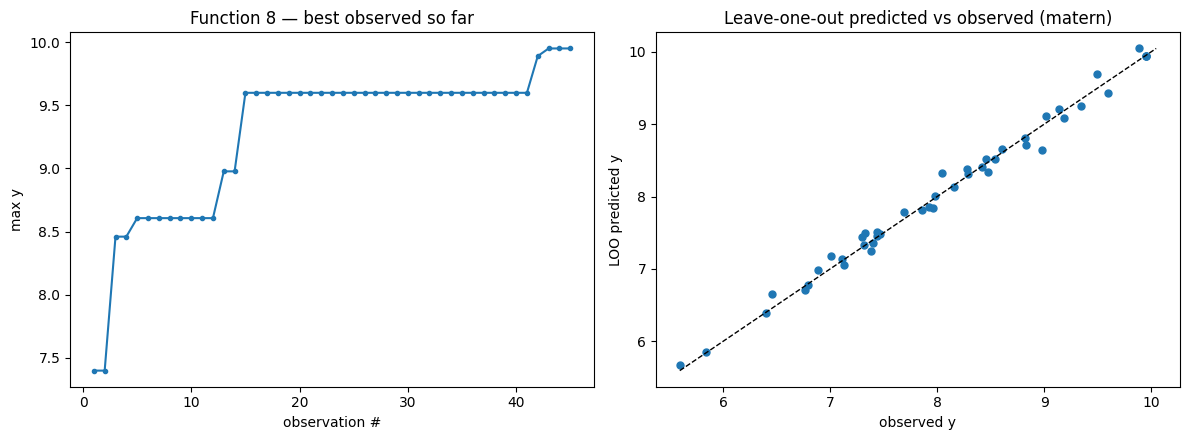

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r["model"]
    beta = PLAN[fid].get("beta", 2.0); xi = PLAN[fid].get("xi", 0.01)
    if m.d == 2:
        bo.plot_2d(m, beta=beta, xi=xi, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, beta=beta, xi=xi, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()

## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.001142-0.002684
f2:  0.920285-0.040059
f3:  0.961192-0.999999-0.406087
f4:  0.377486-0.408091-0.419897-0.447836
f5:  0.000000-0.000000-0.000000-0.000000
f6:  0.352338-0.020636-0.915072-0.017724-0.962404
f7:  0.830424-0.954173-0.844299-0.021565-0.647295-0.980092
f8:  0.121700-0.148903-0.117654-0.213828-0.999999-0.545281-0.258356-0.998299


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)
print("reflection ->", path)

reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week06.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# Week 6 portal returns - already saved into data/fN.csv outside the notebook.
# returned_y = {
#     1: 5.389889495950413e-246,
#     2: -0.002413305651519605,
#     3: -0.05674310266187294,
#     4: 0.13727329037964653,
#     5: 163.1225,
#     6: -2.2946032466527395,
#     7: 0.00784554618687999,
#     8: 9.9498005080854,
# }
#
# Comparison vs week-5 incumbents:
#   f1 5.4e-246 (6 rounds no source signal)
#   f2 -0.002 vs 0.611 (AEI conservative missed again)
#   f3 -0.057 vs -0.035 (AEI conservative kept us close - correct patience)
#   f4 0.137 vs 0.540 (EI HALLUCINATED AGAIN: predicted 0.98, actual 0.14)
#   f5 163 vs 8662 (opposite-corner test: NO hidden peak, (1,1,1,1) confirmed as global)
#   f6 -2.29 vs -0.705 (space_fill probe - informational not score)
#   f7 0.008 vs 1.688 (space_fill probe - informational not score)
#   f8 9.9498 essentially unchanged (MES fully converged)
#
# HEADLINE FINDINGS:
#   1. f5 (1,1,1,1) = 8662 is confirmed as global max — 53x higher than any
#      opposite-corner alternative. Can safely lock this for the final week.
#   2. f4 EI over-confidence pattern is REAL — even at R²=+0.98, the GP dramatically
#      over-predicted (0.98 predicted vs 0.14 actual, 3.8 sigma off). Trust gate
#      catches the model's LOO calibration but not its extrapolation confidence.
#      Need to be more conservative on f4 next week.
#   3. Zero new bests but 3 rounds of pure information probes (f5 test, f6/f7
#      space_fill) means the surrogates should now be significantly better calibrated.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
